In [ ]:
%cd ..

In [2]:
%load_ext autoreload
%autoreload 2

In [28]:
import guides
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from optimizers import SOAP

In [4]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'scalar'

# device 1

In [5]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = lambd/20 * k_0
dy = lambd/20 * k_0

# simulation lengths
core_length_x = 2 * lambd * k_0 # W
core_length_y = 1 * lambd * k_0 # H

substrate_length_x = 3.0 * lambd * k_0 # Xs
substrate_length_y = 2.0 * lambd * k_0 # Ys

# refractive indices
n_core = 1.55
n_substrate = 1.44

In [6]:
weights = [1, 1, 1, 1, 1, 1]
m = 2

In [7]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [8]:
reference_device = guides.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

/home/asmaa/miniconda3/envs/Masters/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1728945388038/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


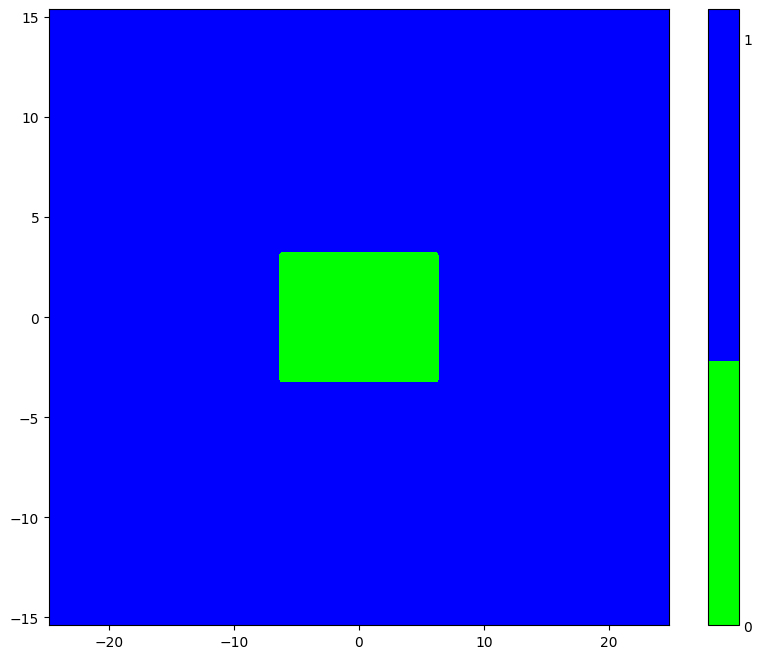

In [9]:
reference_device.plot(dx, dy)

In [34]:
torch.manual_seed(42)
base_model = models.vanilla_network(2, 128, num_modes, 2, 'Siren')
optimizer = SOAP(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[1000, 1500], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 17025


In [35]:
device = guides.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, False)

In [36]:
reference_device_fd = guides.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [37]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

  0%|          | 0/2001 [00:00<?, ?it/s]

num samples 15741


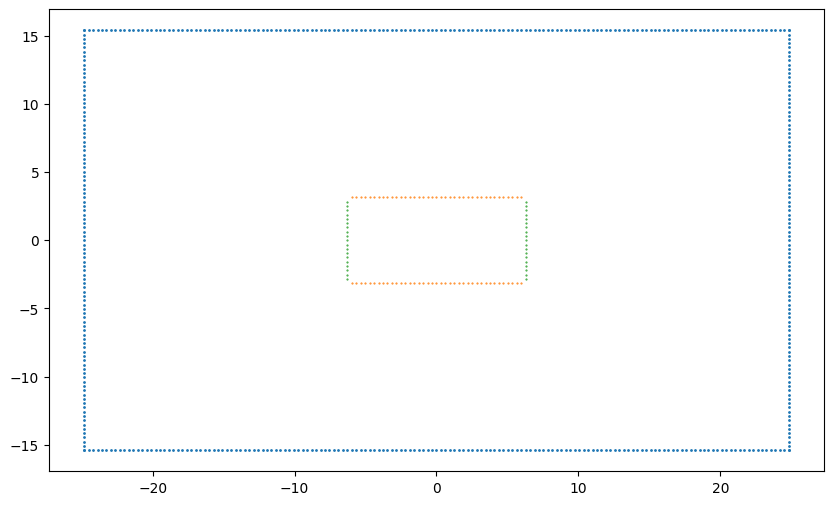

loss1 is  0.00254, loss2 is  0.01089, loss3 is  0.00101, loss4 is  0.00000, loss5 is  0.05725, loss6 is  0.00000, total loss  0.07168, RI value  1.43483:   0%|          | 0/2001 [00:00<?, ?it/s]

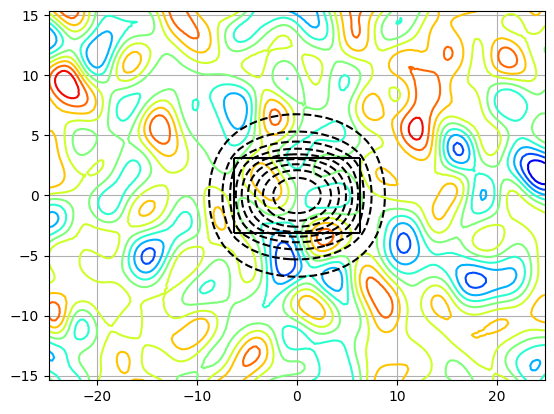

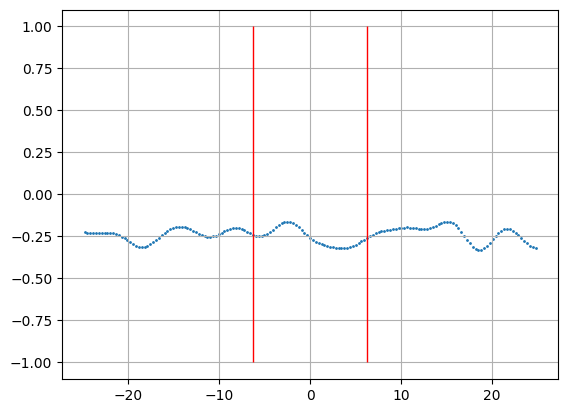

loss1 is  0.02768, loss2 is  0.00004, loss3 is  0.01768, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00000, total loss  0.04541, RI value  1.50782:  25%|██▍       | 498/2001 [00:25<01:21, 18.47it/s]

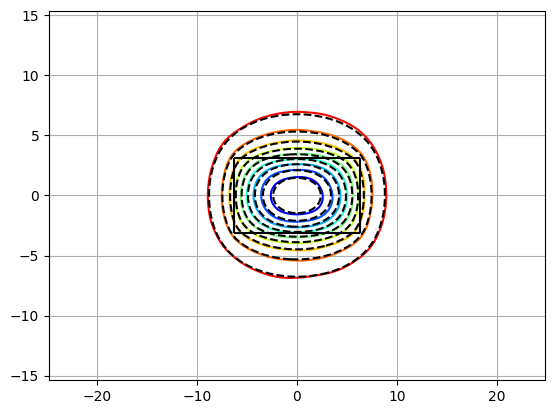

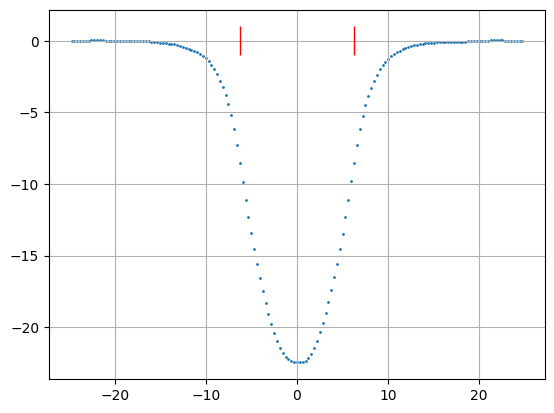

loss1 is  0.04043, loss2 is  0.00002, loss3 is  0.02582, loss4 is  0.00000, loss5 is  0.00323, loss6 is  0.00000, total loss  0.06949, RI value  1.50783:  50%|████▉     | 1000/2001 [00:49<00:39, 25.28it/s]

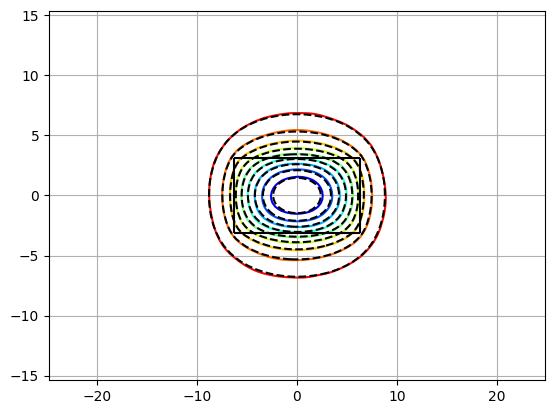

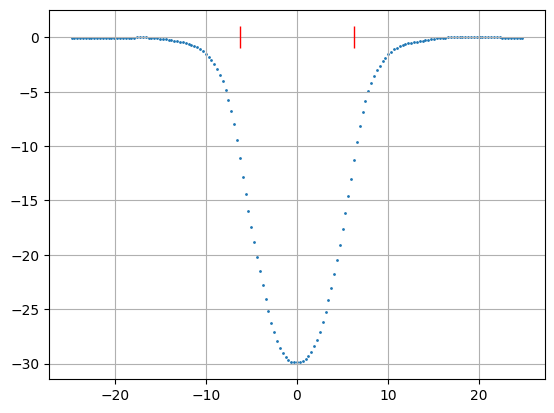

loss1 is  0.03855, loss2 is  0.00002, loss3 is  0.02461, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00000, total loss  0.06318, RI value  1.50792:  75%|███████▍  | 1498/2001 [01:12<00:14, 35.40it/s]

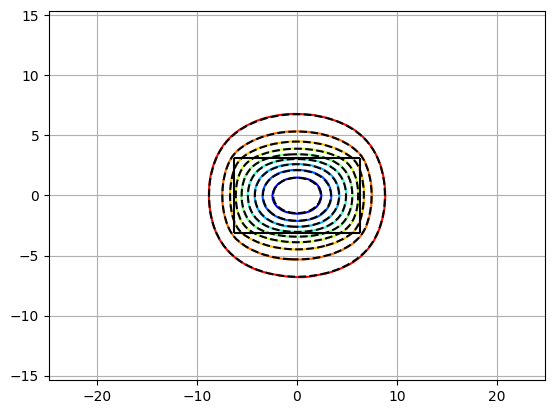

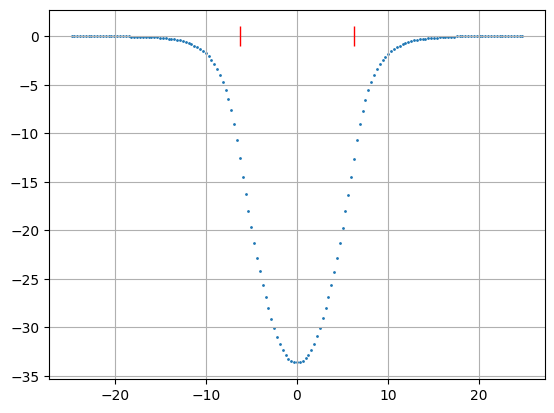

loss1 is  0.04015, loss2 is  0.00002, loss3 is  0.02563, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00000, total loss  0.06580, RI value  1.50788: 100%|█████████▉| 1999/2001 [01:38<00:00, 19.22it/s]

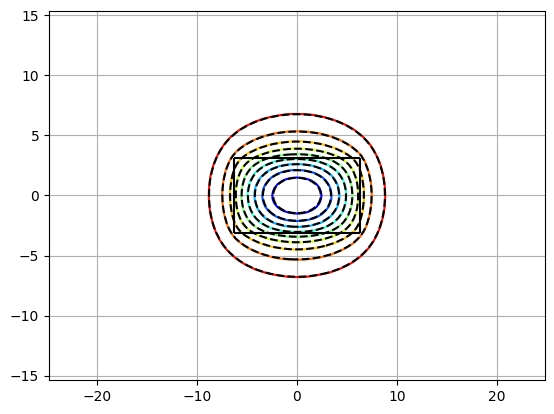

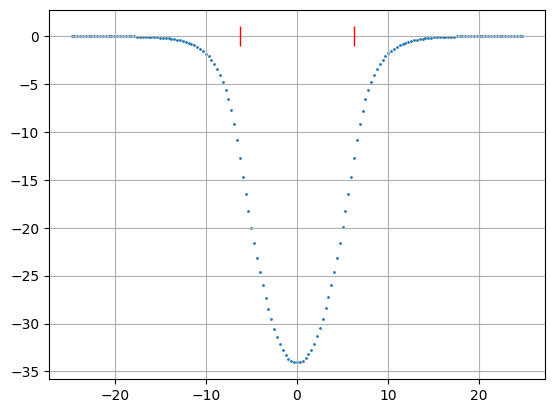

loss1 is  0.04015, loss2 is  0.00002, loss3 is  0.02563, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00000, total loss  0.06580, RI value  1.50788: 100%|██████████| 2001/2001 [01:38<00:00, 20.28it/s]


In [38]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(2001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True)

In [39]:
base_model.to('cpu');
base_model.to(torch.float64);

In [40]:
xy = torch.arange(0, device.total_length_x/2, dx, dtype=torch.float64).reshape(-1, 1)
xy = torch.cat((-torch.flip(xy, dims=(0,))[:-1], xy))

xy = torch.cat((xy, torch.full_like(xy, 0*dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, (reference_device.make_features(xy).view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

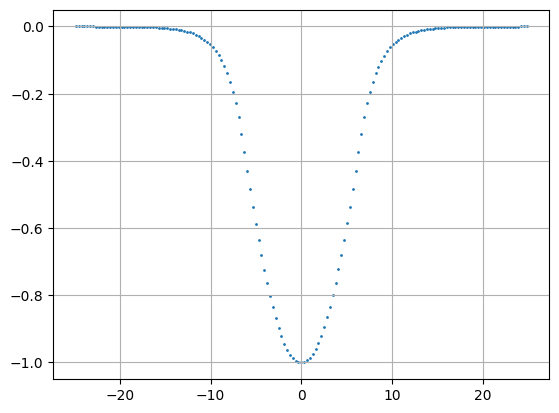

In [41]:
plt.scatter(xy[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [42]:
reference_device_fd = guides.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy, num_modes=num_modes)

In [43]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)

print(np.sqrt(RI_squared))

[1.50799194]


In [44]:
Nx = int(sum(lengths_x)/(dx)) - 1
Ny = int(sum(lengths_y)/(dy)) - 1
print(len(u_fd), Nx*Ny)

15741 15741


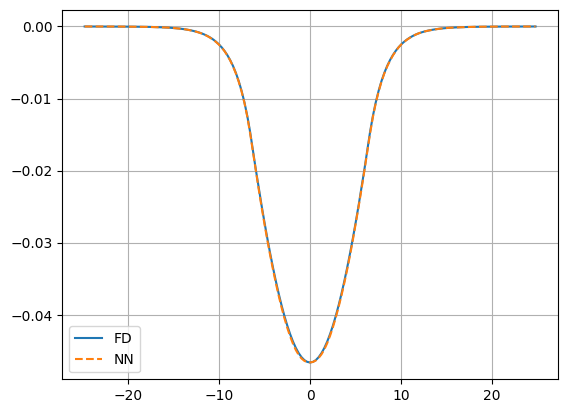

In [47]:
i = int(Ny//2)
row_length = Nx
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u_fd[row_length * i:row_length * (i + 1), 0], markersize=3, label='FD')
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u*np.max(np.abs(u_fd[row_length * i:row_length * (i + 1), 0])), markersize=3, label='NN', linestyle='dashed')
plt.legend()
plt.grid()

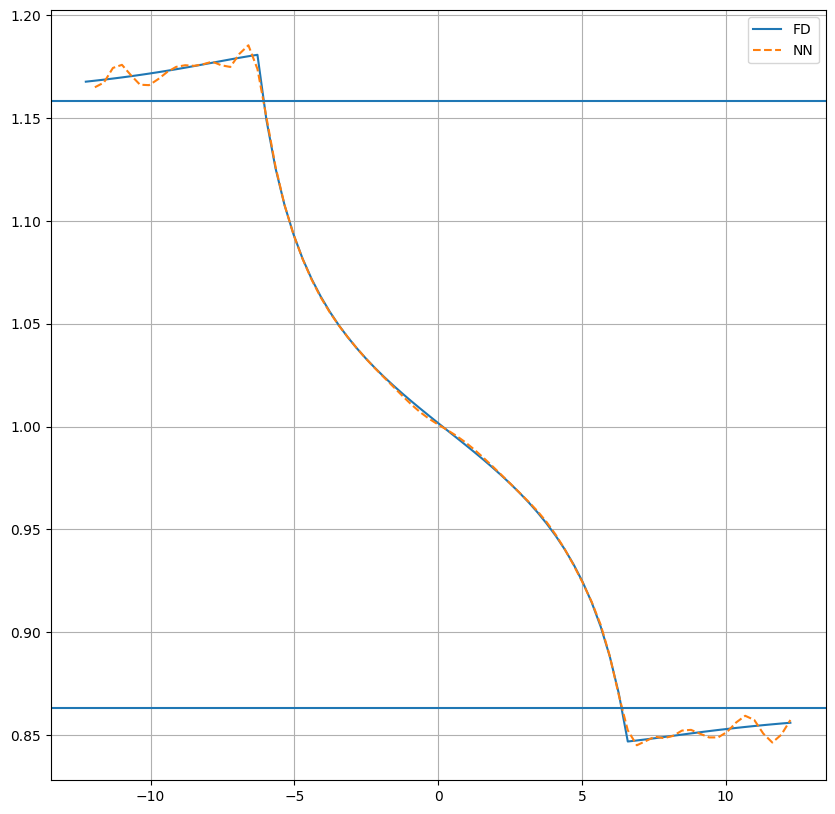

In [48]:
ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD')

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN')
plt.axhline(y=(n_core**2)/(n_substrate**2))
plt.axhline(y=(n_substrate**2)/(n_core**2))
# plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()